# AI Maintenance & Optimization — Data Collection & Cleaning

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (Kaggle)
**Source:** kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
**Downloaded via:** Kaggle API (reproducible — anyone can re-run with their own kaggle.json)

## Cleaning steps performed
1. Loaded raw CSV and inspected shape, dtypes, nulls, duplicates
2. Cleaned column names (removed units/brackets, lowercased, underscores)
3. Removed duplicate rows
4. Checked and handled missing values (none found in raw dataset, verified explicitly)
5. Flagged outliers using IQR method (not removed — kept for ML team to decide, as high sensor readings may indicate real failure signals)
6. Ran sanity checks on value ranges (temperature, rpm, torque, tool wear)
7. Engineered features: `power` (from torque + rpm), `temp_diff` (process - air temperature)
8. Encoded `type` column (L/M/H) as `type_encoded`
9. Renamed columns to align with project's sensor_readings schema

## Known limitations
- Dataset does not include `vibration` or `pressure` readings (present in project schema but not in this dataset) — flagged for team awareness, may need supplementary data later
- Class imbalance in `machine_failure` target (~3% positive) — important for ML team during model training

## Column reference
| Column | Meaning |
|---|---|
| air_temperature | Ambient temperature (K) |
| process_temperature | Process temperature (K) |
| rpm | Rotational speed |
| torque | Torque (Nm) |
| tool_wear | Tool wear (min) |
| power_consumption | Derived: torque × rpm |
| temp_diff | Derived: process temp − air temp |
| machine_failure | Target: 1 = failure occurred |

## Setup & Data Loading


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d stephanmatzka/predictive-maintenance-dataset-ai4i-2020
!unzip predictive-maintenance-dataset-ai4i-2020.zip

df = pd.read_csv('ai4i2020.csv')
df.head()

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
License(s): CC-BY-NC-SA-4.0
predictive-maintenance-dataset-ai4i-2020.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  predictive-maintenance-dataset-ai4i-2020.zip
replace ai4i2020.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: [n]o
error:  invalid response [[n]o]
replace ai4i2020.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: o
error:  invalid response [o]
replace ai4i2020.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


##Team note:

Dataset downloaded via Kaggle API — anyone on the team can re-run this cell with their own kaggle.json to get the exact same raw data, no manual file sharing needed.

##Initial Look

In [12]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df['Type'].value_counts()
df['Machine failure'].value_counts(normalize=True)  # check class imbalance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,proportion
Machine failure,
0,0.9661
1,0.0339


##Clean Column Names

In [13]:
df.columns = (df.columns
              .str.strip()
              .str.replace(r'\[.*?\]', '', regex=True)
              .str.strip()
              .str.replace(' ', '_')
              .str.lower())
df.columns.tolist()

['udi',
 'product_id',
 'type',
 'air_temperature',
 'process_temperature',
 'rotational_speed',
 'torque',
 'tool_wear',
 'machine_failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

##Handle Duplicates & Missing Values

In [14]:
df = df.drop_duplicates()
df.isnull().sum()


,0
udi,0
product_id,0
type,0
air_temperature,0
process_temperature,0
rotational_speed,0
torque,0
tool_wear,0
machine_failure,0
twf,0


##Outlier Check (IQR method)

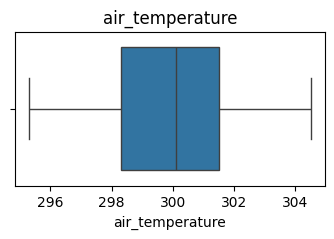

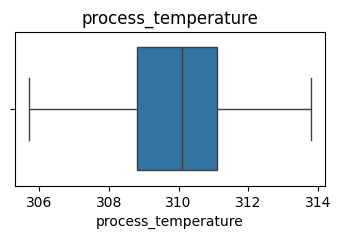

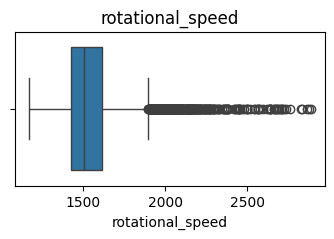

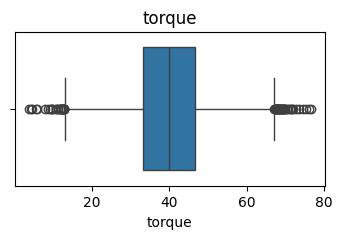

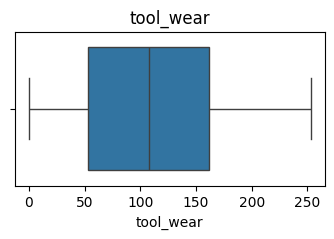

air_temperature: 0 potential outliers
process_temperature: 0 potential outliers
rotational_speed: 418 potential outliers
torque: 69 potential outliers
tool_wear: 0 potential outliers


In [15]:
num_cols = ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear']

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

def flag_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

for col in num_cols:
    outliers = flag_outliers_iqr(df[col])
    print(f"{col}: {outliers.sum()} potential outliers")

##Data Validation

In [16]:
assert df['air_temperature'].between(280, 320).all(), "unexpected temp range"
assert (df['rotational_speed'] > 0).all(), "invalid rpm"
assert (df['torque'] >= 0).all(), "invalid torque"
assert (df['tool_wear'] >= 0).all(), "invalid tool wear"

##Feature Engineering

In [17]:
df['power'] = 2 * np.pi * df['rotational_speed'] * df['torque'] / 60  # Watts
df['temp_diff'] = df['process_temperature'] - df['air_temperature']

# Encode Type (L/M/H)
df['type_encoded'] = df['type'].map({'L': 0, 'M': 1, 'H': 2})

##Rename to Match

In [18]:
df = df.rename(columns={
    'rotational_speed': 'rpm',
    'power': 'power_consumption'
})
# Note for team: vibration & pressure not present in this dataset — flag as future enhancement or find supplementary sensor data

##Export Clean Data

In [19]:
df.to_csv('ai4i2020_cleaned.csv', index=False)
files.download('ai4i2020_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>